### Self Attention Mechanism
* What is Self-Attention?
    * Allows a modell to dynamically focus on different parts of an input sequence when ecoding a token
    * It captures dependencies across all tokens in as sequence , enabling context-aware represntations
    * Steps in Self-Attention
        * Compute Attention Scores:
            * Calculate dot products between the query ande key vectors for all tokens
            * Scale by tghe square root of the dimnension (d_k) to stabilize gradients
            * Apply softmax function to convert scores into probabilities
        * Weight Values
            * Use the attention scores to compute a weighted sum of value (V) vectors
                * Attention(Q,K,V)= softmax((Q.K^T) / root(d_k)). V
                

### Multi Head Attention
* what is Mult0Head Attention
    * applies several attention mechanisms in parallel
    8 each sttention "head" focuses on different aspects of the sequence
* Steps:
    * Linear Projections
        * Project Q,K, V  into multiple subspaces using learned weight matrices
    * Apply Self-Attention
        * Perform self-attention for each head independently
    * Concatenate Outputs
        * Combine outputs from all heads
    * Final Linear Projection
        * Project concatenated outputs back into the original dimensions
            * MultiHead(Q,K,V)= Concat(head_1,head_2,..., head_h) W^o

In [7]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# Define Q, K,V
def generate_data (seq_len,embed_dim):
    np.random.seed(42)
    return torch.tensor(np.random.rand(seq_len, embed_dim))

sequence_length = 4
embedding_dim = 3
query = generate_data(sequence_length, embedding_dim)
key = generate_data(sequence_length, embedding_dim)
value = generate_data(sequence_length, embedding_dim)

In [6]:
# Compute attention scores
scores = torch.matmul(query, key.T)/ np.sqrt(embedding_dim)

attention_weights = torch.functional.F.softmax(scores)

context = np.dot(attention_weights, value)

print(f"Attention Weights:", attention_weights)
print(f"Context  Vector: ", context)

Attention Weights: tensor([[0.3238, 0.1722, 0.2731, 0.2309],
        [0.2572, 0.2456, 0.2261, 0.2711],
        [0.3174, 0.1760, 0.2877, 0.2189],
        [0.2566, 0.2018, 0.2093, 0.3323]], dtype=torch.float64)
Context  Vector:  [[0.40373714 0.57596851 0.65199056]
 [0.44847108 0.48422419 0.62544482]
 [0.39596332 0.58290558 0.64506672]
 [0.46435514 0.46358349 0.66743626]]


/tmp/ipykernel_75570/4266168336.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  attention_weights = torch.functional.F.softmax(scores)
/tmp/ipykernel_75570/4266168336.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  context = np.dot(attention_weights, value)


In [12]:

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention,self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim//num_heads

        assert embed_dim % num_heads ==0 , "Embedding dimension must be divisible by number num_heads"
        
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)

        self.value = nn.Linear(embed_dim, embed_dim)
        self.out = nn.Linear(embed_dim, embed_dim)        
    
    def forward(self,x):
        batch_size = x.size(0)
        # Linear Projections
        q = self.query(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        k =self.key(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)
        v =self.value(x).view(batch_size, -1, self.num_heads, self.head_dim).transpose(1,2)

        #  Compute attention scores
        scores = torch.matmul(q,k.transpose(-2,-1))/ np.sqrt(self.head_dim)

        attention_weights = F.softmax(scores, dim=-1)

        # copmpute context
        context = torch.matmul(attention_weights, v).transpose(1,2).contiguous().view(batch_size,-1,self.embed_dim)

        return self.out(context,), attention_weights
    


In [13]:
# Sample input
seq_len , embed_dim = 4, 8
x = torch.rand(1, seq_len, embed_dim)

# Instantiate and test
mha = MultiHeadAttention(embed_dim, num_heads=2)

context, attention_weights = mha(x)

print("Attention Weights", attention_weights)
print("Context Vectors", context)

Attention Weights tensor([[[[0.2570, 0.2665, 0.2338, 0.2427],
          [0.2544, 0.2731, 0.2256, 0.2469],
          [0.2570, 0.2730, 0.2211, 0.2489],
          [0.2579, 0.2632, 0.2258, 0.2530]],

         [[0.2469, 0.2561, 0.2468, 0.2502],
          [0.2550, 0.2420, 0.2567, 0.2463],
          [0.2439, 0.2352, 0.2552, 0.2657],
          [0.2622, 0.2352, 0.2690, 0.2335]]]], grad_fn=<SoftmaxBackward0>)
Context Vectors tensor([[[-0.5237, -0.3541,  0.0242,  0.2850,  0.0948, -0.1055,  0.1829,
          -0.0080],
         [-0.5265, -0.3545,  0.0259,  0.2879,  0.0948, -0.1083,  0.1819,
          -0.0059],
         [-0.5267, -0.3539,  0.0258,  0.2889,  0.0944, -0.1087,  0.1809,
          -0.0062],
         [-0.5288, -0.3552,  0.0300,  0.2870,  0.0933, -0.1082,  0.1845,
          -0.0064]]], grad_fn=<ViewBackward0>)


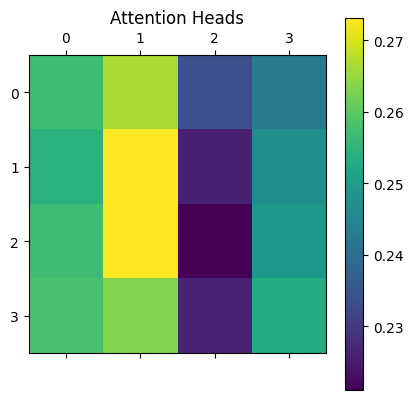

In [14]:
import matplotlib.pyplot as plt

# visualize attention weights for a single head
plt.matshow(attention_weights[0,0].detach().numpy(),cmap="viridis")
plt.colorbar()
plt.title("Attention Heads")
plt.show()